# U-Net Model for Cardiac Ultrasound ROI Segmentation

## Abstract

This notebook implements a U-Net architecture for automated region of interest (ROI) segmentation in cardiac ultrasound images. The model processes echocardiogram data from the MIMIC-IV-ECHO dataset for automated ROI extraction in clinical analysis and privacy-preserving applications.

## Key Features

- U-Net encoder-decoder architecture with skip connections
- Trained on MIMIC-IV-ECHO echocardiogram data from PhysioNet
- Automated ultrasound ROI segmentation and de-identification
- Support for standard image formats (PNG, JPG)
- Binary mask output for ROI extraction and cropping
- Applications in medical research and clinical preprocessing

## Problem Statement

Automated ROI segmentation addresses several clinical challenges:

1. Reduces manual annotation time and variability
2. Standardizes preprocessing across datasets
3. Enables privacy-preserving image processing
4. Supports batch processing workflows
5. Maintains diagnostic information quality

## Dataset

The implementation uses the MIMIC-IV-ECHO dataset from PhysioNet:
- High-quality echocardiogram images with clinical metadata
- Standardized format for machine learning research
- De-identified data compliant with privacy protocols
- Diverse cardiac ultrasound cases

**Note**: PhysioNet access and data use agreement compliance required.

---

## Table of Contents

1. [Environment Setup](#environment-setup)
2. [Data Loading and Preprocessing](#data-loading-and-preprocessing)  
3. [Model Architecture](#model-architecture)
4. [Training](#training)
5. [Model Evaluation](#model-evaluation)
6. [Inference Pipeline](#inference-pipeline)
7. [Results and Usage Examples](#results-and-usage-examples)

---

## Methods

### Environment Setup

Required dependencies:
- TensorFlow/Keras for deep learning
- OpenCV for image processing
- NumPy for numerical operations
- Matplotlib for visualization
- Scikit-learn for model evaluation

### Hardware Requirements

- GPU recommended for training
- Minimum 8GB RAM (16GB+ recommended)
- Sufficient storage for datasets and models

### Data Requirements

- **Images**: Ultrasound images in standard formats (PNG, JPG, etc.)
- **Masks**: Corresponding binary masks for ROI regions
- **Structure**: Organized in separate directories for images and masks

## Grayscale Augmentation Visualization

We allow arbitrary user image formats (RGB, BGR-loaded, etc.) for raw exploration, but for ANY model-facing path (training or inference) we standardize to single‑channel normalized grayscale (H, W, 1).

This section rebuilds the augmentation visualization so that:
- Input shown to augmentation is forced grayscale (so masks and images share a single channel semantics)
- Augmentations are applied jointly to image + mask without creating variables inside the `tf.data` graph repeatedly
- Spatial transforms are deterministic per pair (same transform to image and mask)
- Intensity transforms (if enabled) only affect the image channel and preserve mask binary values

We keep raw RGB preview (elsewhere) untouched; ONLY this visualization is grayscale‑specific to mirror actual model ingestion.

Next cells define helpers and display a grid of augmented (image, mask, overlay) triplets.

In [1]:
# Core libraries
import os
import warnings
from glob import glob
from typing import Tuple, List, Optional

# Data manipulation and processing
import numpy as np
import cv2

# Machine learning and deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split

# Visualization
import matplotlib.pyplot as plt

# Configure environment
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

# TensorFlow Metal GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"✓ Metal GPU detected: {len(gpus)} device(s)")
    except RuntimeError:
        print("Metal GPU available but memory growth setting failed")
else:
    print("No Metal GPU detected - using CPU")

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")

✓ Metal GPU detected: 1 device(s)
TensorFlow version: 2.16.2
NumPy version: 1.26.4
OpenCV version: 4.11.0


### Configuration Parameters

The following section defines all the hyperparameters and paths used throughout the training and inference pipeline:

In [4]:
# ==============================================================================
# CONFIGURATION AND HYPERPARAMETERS
# ==============================================================================

# Dataset configuration - Using organized train/val/test splits

TRAIN_IMAGE_DIR = "data/train/images"       # Training images
TRAIN_MASK_DIR = "data/train/masks"       # Training masks
VAL_IMAGE_DIR = "data/val/images"         # Validation images
VAL_MASK_DIR = "data/val/masks"           # Validation masks
TEST_IMAGE_DIR = "data/test/images"       # Test images
TEST_MASK_DIR = "data/test/masks"         # Test masks

MODEL_SAVE_PATH = "models/unet_EchoROI.keras"  # Path to save/load the trained model

# Model hyperparameters
IMG_SIZE = (256, 256)  # Input image dimensions for UNET
BATCH_SIZE = 32         # Batch size for training (adjust based on GPU memory)
EPOCHS = 50            # Number of training epochs
LEARNING_RATE = 1e-4   # Adam optimizer learning rate
VALIDATION_SPLIT = 0.2 # Fraction of data used for validation

# Data augmentation parameters
AUGMENTATION = True    # Enable/disable data augmentation
ROTATION_RANGE = 15    # Random rotation range in degrees
WIDTH_SHIFT = 0.1      # Random horizontal shift
HEIGHT_SHIFT = 0.1     # Random vertical shift

# Inference parameters
MASK_THRESHOLD = 0.5   # Threshold for binary mask prediction
OUTPUT_SIZE = (224, 224)  # Final output size for downstream processing

print("Configuration parameters initialized")
print(f"Model input size: {IMG_SIZE}")
print(f"Training configuration: {EPOCHS} epochs, batch size {BATCH_SIZE}")
print(f"Organized dataset structure:")
print(f"  - Train Images: {TRAIN_IMAGE_DIR}/")
print(f"  - Train Masks:  {TRAIN_MASK_DIR}/")
print(f"  - Val Images:   {VAL_IMAGE_DIR}/")
print(f"  - Val Masks:    {VAL_MASK_DIR}/")
print(f"  - Test Images:  {TEST_IMAGE_DIR}/")
print(f"  - Test Masks:   {TEST_MASK_DIR}/")
print(f"  - Model:        {MODEL_SAVE_PATH}")

Configuration parameters initialized
Model input size: (256, 256)
Training configuration: 50 epochs, batch size 32
Organized dataset structure:
  - Train Images: data/train/images/
  - Train Masks:  data/train/masks/
  - Val Images:   data/val/images/
  - Val Masks:    data/val/masks/
  - Test Images:  data/test/images/
  - Test Masks:   data/test/masks/
  - Model:        models/unet_EchoROI.keras


---

## 2. Data Loading and Preprocessing

### Dataset Description

This implementation is designed to work with echocardiogram data from the **MIMIC-IV-ECHO: Echocardiogram Matched Dataset**, a comprehensive collection of cardiac ultrasound images from PhysioNet. The dataset structure:

- **Source**: MIMIC-IV-ECHO dataset from PhysioNet
- **Content**: Echocardiogram images with matched clinical data
- **Images**: Cardiac ultrasound images in standard formats (PNG, JPG, etc.)
- **Masks**: Binary ROI masks indicating the ultrasound sector region
- **Annotation**: Manual ROI annotations created using annotation tools
- **Format**: Images automatically resized to 256×256 pixels for processing

### MIMIC-IV-ECHO Dataset

The MIMIC-IV-ECHO dataset provides:
- **Clinical Integration**: Echocardiogram images matched with clinical data
- **Diverse Cases**: Wide range of cardiac conditions and image qualities  
- **Research Quality**: Standardized format suitable for machine learning research
- **Privacy Compliance**: De-identified data following PhysioNet protocols

**Note**: Users should obtain appropriate access to the MIMIC-IV-ECHO dataset through PhysioNet and follow all data use agreements and ethical guidelines.

### Preprocessing Pipeline

The preprocessing pipeline includes the following steps:

1. **Aspect Ratio Preservation**: Images are resized using padding to maintain aspect ratio
2. **Normalization**: Pixel values normalized to [0, 1] range
3. **Mask Binarization**: Masks converted to binary format (0 or 1)
4. **Data Splitting**: Train/validation split with stratification

### Key Functions

In [5]:
# ==============================================================================
# DATA PREPROCESSING FUNCTIONS
# ==============================================================================

def resize_with_padding(img: np.ndarray, target_size: Tuple[int, int] = (256, 256)) -> np.ndarray:
    """
    Resize image while preserving aspect ratio using padding.
    Critical to preserve aspect ratio for medical images.
    
    Parameters
    ----------
    img : np.ndarray
        Input image (grayscale or RGB)
    target_size : Tuple[int, int]
        Target dimensions (height, width)
    
    Returns
    -------
    np.ndarray
        Resized image with padding
    """
    h, w = img.shape[:2]
    
    # Calculate scaling factor to preserve aspect ratio
    scale = min(target_size[1] / w, target_size[0] / h)
    new_w, new_h = int(w * scale), int(h * scale)
    
    # Resize image
    resized = cv2.resize(img, (new_w, new_h))

    # Calculate padding values
    top = (target_size[0] - new_h) // 2
    bottom = target_size[0] - new_h - top
    left = (target_size[1] - new_w) // 2
    right = target_size[1] - new_w - left

    # Apply padding based on image type
    if img.ndim == 2:  # Grayscale image
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                  cv2.BORDER_CONSTANT, value=0)
    else:  # RGB image
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                  cv2.BORDER_CONSTANT, value=[0, 0, 0])

    return padded

def validate_data_paths(image_dir: str, mask_dir: str) -> bool:
    """
    Validate that data directories exist and contain matching files.
    
    Parameters
    ----------
    image_dir : str
        Path to image directory
    mask_dir : str
        Path to mask directory
    
    Returns
    -------
    bool
        True if validation passes
        
    Raises
    ------
    FileNotFoundError
        If directories do not exist
    ValueError
        If no matching files are found
    """
    if not os.path.exists(image_dir):
        raise FileNotFoundError(f"Image directory not found: {image_dir}")
    
    if not os.path.exists(mask_dir):
        raise FileNotFoundError(f"Mask directory not found: {mask_dir}")
    
    image_files = sorted(glob(os.path.join(image_dir, "*.png")))
    mask_files = sorted(glob(os.path.join(mask_dir, "*.png")))
    
    if len(image_files) == 0:
        raise ValueError(f"No PNG images found in {image_dir}")
    
    if len(mask_files) == 0:
        raise ValueError(f"No PNG masks found in {mask_dir}")
    
    if len(image_files) != len(mask_files):
        raise ValueError(f"Mismatch: {len(image_files)} images vs {len(mask_files)} masks")
    
    print(f"Data validation successful: {len(image_files)} image-mask pairs found")
    return True

def to_grayscale(x):
    x = tf.convert_to_tensor(x, tf.float32)
    if x.shape.rank == 2:
        x = x[..., None]
    if x.shape[-1] == 3:
        r,g,b = tf.unstack(x, axis=-1)
        x = 0.2989*r + 0.5870*g + 0.1140*b
        x = x[..., None]
    x = tf.clip_by_value(x, 0., 1.) if tf.reduce_max(x) <= 1.5 else tf.clip_by_value(x/255.,0.,1.)
    return x

# Test the resize function with different input types
print("Testing resize_with_padding function...")
test_img_gray = np.random.randint(0, 255, (100, 150), dtype=np.uint8)
test_img_rgb = np.random.randint(0, 255, (100, 150, 3), dtype=np.uint8)

resized_gray = resize_with_padding(test_img_gray, (256, 256))
resized_rgb = resize_with_padding(test_img_rgb, (256, 256))

print(f"Grayscale: {test_img_gray.shape} → {resized_gray.shape}")
print(f"RGB: {test_img_rgb.shape} → {resized_rgb.shape}")
print("Resize function validated successfully")

Testing resize_with_padding function...
Grayscale: (100, 150) → (256, 256)
RGB: (100, 150, 3) → (256, 256, 3)
Resize function validated successfully


In [13]:
# ==============================================================================
# DATA AUGMENTATION PIPELINE  (UNIFIED / GRAYSCALE-STRICT + COMPAT FALLBACKS)
# ==============================================================================

AUG_ROT_DEG      = ROTATION_RANGE
AUG_H_SHIFT      = HEIGHT_SHIFT
AUG_W_SHIFT      = WIDTH_SHIFT
AUG_ZOOM_RANGE   = 0.10
AUG_BRIGHT_RANGE = 0.20          # interpreted as ± factor
AUG_CONTRAST_F   = 0.20
AUG_NOISE_PROB   = 0.50
AUG_NOISE_STD    = 0.02

# Check TF brightness / contrast support
try:
    from tensorflow.keras.layers import RandomBrightness, RandomContrast
    _HAS_KERAS_INTENSITY = True
except Exception:
    _HAS_KERAS_INTENSITY = False

# Spatial layer stack (shared image+mask)
_SPATIAL_BASE = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(AUG_ROT_DEG / 360.0, fill_mode='reflect'),
    tf.keras.layers.RandomTranslation(height_factor=AUG_H_SHIFT,
                                      width_factor=AUG_W_SHIFT,
                                      fill_mode='reflect'),
    tf.keras.layers.RandomZoom(height_factor=(-AUG_ZOOM_RANGE, AUG_ZOOM_RANGE),
                               width_factor=(-AUG_ZOOM_RANGE, AUG_ZOOM_RANGE),
                               fill_mode='reflect'),
], name="spatial_pair_aug")

# Intensity stack (image-only) with fallback
if _HAS_KERAS_INTENSITY:
    _INTENSITY_BASE = tf.keras.Sequential([
        tf.keras.layers.RandomBrightness(factor=AUG_BRIGHT_RANGE),
        tf.keras.layers.RandomContrast(factor=AUG_CONTRAST_F),
    ], name="intensity_img_aug")
else:
    class FallbackIntensity(tf.keras.layers.Layer):
        def call(self, x, training=False):
            if not training:
                return x
            # Brightness: add delta in [-AUG_BRIGHT_RANGE, +AUG_BRIGHT_RANGE]
            delta = tf.random.uniform([], -AUG_BRIGHT_RANGE, AUG_BRIGHT_RANGE)
            x = tf.clip_by_value(x + delta, 0., 1.)
            # Contrast: factor in [1-contr, 1+contr]
            c_factor = tf.random.uniform([], 1.0 - AUG_CONTRAST_F, 1.0 + AUG_CONTRAST_F)
            mean = tf.reduce_mean(x, axis=[1,2,3], keepdims=True)
            x = tf.clip_by_value((x - mean) * c_factor + mean, 0., 1.)
            return x
    _INTENSITY_BASE = FallbackIntensity(name="intensity_img_aug_fallback")

# Build (prevent variable creation later)
_SPATIAL_BASE.build(input_shape=(None, IMG_SIZE[0], IMG_SIZE[1], 2))
_INTENSITY_BASE.build(input_shape=(None, IMG_SIZE[0], IMG_SIZE[1], 1))

def _ensure_batched(x: tf.Tensor):
    """Return (x_batched, added_batch_flag)."""
    return (x[None, ...], True) if x.shape.rank == 3 else (x, False)

def _maybe_unbatch(x: tf.Tensor, added: bool):
    return x[0] if added else x

def _morphological_close(mask: tf.Tensor, k: int = 3) -> tf.Tensor:
    mask = tf.cast(mask > 0.5, tf.float32)
    r = mask.shape.rank
    if r == 3:      # (H,W,1)
        m4 = mask[None, ...]
        squeeze = True
    elif r == 4:    # (B,H,W,1)
        m4 = mask
        squeeze = False
    else:
        raise ValueError(f"mask must be rank 3 or 4, got rank {r}")

    dil = tf.nn.max_pool(m4, ksize=[1,k,k,1], strides=[1,1,1,1], padding='SAME')
    ero = 1. - tf.nn.max_pool(1. - dil, ksize=[1,k,k,1], strides=[1,1,1,1], padding='SAME')
    out = ero[0] if squeeze else ero
    return tf.cast(out > 0.5, tf.float32)

def _enforce_shapes_and_ranges(image: tf.Tensor, mask: tf.Tensor):
    image = to_grayscale(image)
    mask  = to_grayscale(mask)
    image = tf.cast(tf.clip_by_value(image, 0., 1.), tf.float32)
    mask  = tf.cast(mask > 0.5, tf.float32)
    return image, mask

def augment_image_and_mask(image: tf.Tensor,
                           mask: tf.Tensor,
                           apply_intensity=True,
                           apply_noise=True,
                           closing=True):
    image, mask = _enforce_shapes_and_ranges(image, mask)

    # Ensure batch for all preprocessing layers and the fallback intensity
    image, added = _ensure_batched(image)   # (B,H,W,1)
    mask,  _     = _ensure_batched(mask)    # (B,H,W,1)

    # Synchronized spatial augs
    pair = tf.concat([image, mask], axis=-1)           # (B,H,W,2)
    pair = _SPATIAL_BASE(pair, training=True)
    aug_img = pair[..., :1]
    aug_msk = tf.cast(pair[..., 1:] > 0.5, tf.float32)

    # Image-only intensity augs
    if apply_intensity:
        aug_img = _INTENSITY_BASE(aug_img, training=True)

    # Optional noise
    if apply_noise and tf.random.uniform(()) < AUG_NOISE_PROB:
        aug_img = tf.clip_by_value(aug_img + tf.random.normal(tf.shape(aug_img), stddev=AUG_NOISE_STD), 0., 1.)

    # Optional morphological cleanup (now batch-aware)
    if closing:
        aug_msk = _morphological_close(aug_msk, k=3)

    # Return to original (unbatched) shape if we added a batch
    aug_img = _maybe_unbatch(aug_img, added)
    aug_msk = _maybe_unbatch(aug_msk, added)
    return tf.clip_by_value(aug_img, 0., 1.), tf.cast(aug_msk > 0.5, tf.float32)

def visualize_augment(image, mask,
                      apply_spatial=True,
                      apply_intensity=True,
                      apply_noise=True):
    image, mask = _enforce_shapes_and_ranges(image, mask)
    if not apply_spatial:
        x, added = _ensure_batched(image)
        if apply_intensity:
            x = _INTENSITY_BASE(x, training=True)
        if apply_noise and tf.random.uniform(()) < AUG_NOISE_PROB:
            x = tf.clip_by_value(x + tf.random.normal(tf.shape(x), stddev=AUG_NOISE_STD), 0., 1.)
        return _maybe_unbatch(x, added), mask
    return augment_image_and_mask(image, mask, apply_intensity, apply_noise, closing=True)

def test_augmentation_pipeline(X_sample, Y_sample, num_augmentations=6):
    print("Testing Data Augmentation Pipeline...")
    print("="*60)
    X_sample, Y_sample = _enforce_shapes_and_ranges(X_sample, Y_sample)
    image_tensor = tf.convert_to_tensor(X_sample, tf.float32)
    mask_tensor  = tf.convert_to_tensor(Y_sample, tf.float32)

    configs = [
        {'spatial': True,  'intensity': False, 'noise': False, 'name': 'Spatial'},
        {'spatial': False, 'intensity': True,  'noise': False, 'name': 'Intensity'},
        {'spatial': False, 'intensity': False, 'noise': True,  'name': 'Noise'},
        {'spatial': True,  'intensity': True,  'noise': False, 'name': 'Spatial+Intensity'},
        {'spatial': True,  'intensity': False, 'noise': True,  'name': 'Spatial+Noise'},
        {'spatial': True,  'intensity': True,  'noise': True,  'name': 'All'}
    ][:num_augmentations]

    fig, axes = plt.subplots(4, len(configs)+1, figsize=(2.8*(len(configs)+1), 11))

    axes[0,0].imshow(image_tensor.numpy().squeeze(), cmap='gray'); axes[0,0].set_title('Original Image'); axes[0,0].axis('off')
    axes[1,0].imshow(mask_tensor.numpy().squeeze(), cmap='gray'); axes[1,0].set_title('Original Mask'); axes[1,0].axis('off')
    ov = np.stack([image_tensor.numpy().squeeze()]*3, axis=-1)
    ov_mask = ov.copy(); ov_mask[mask_tensor.numpy().squeeze() > 0.5, 0] = 1.
    blended = 0.7*ov + 0.3*ov_mask
    axes[2,0].imshow(blended); axes[2,0].set_title('Overlay'); axes[2,0].axis('off')
    orig_cov = np.mean(mask_tensor.numpy().squeeze() > 0.5)
    axes[3,0].text(0.05,0.5,f'ROI {orig_cov:.3f}\\n({orig_cov*100:.1f}%)',va='center'); axes[3,0].axis('off')

    for i,cfg in enumerate(configs):
        img_aug, mask_aug = visualize_augment(image_tensor, mask_tensor,
                                              apply_spatial=cfg['spatial'],
                                              apply_intensity=cfg['intensity'],
                                              apply_noise=cfg['noise'])
        img_np = img_aug.numpy().squeeze()
        mask_np= mask_aug.numpy().squeeze()
        uniq = np.unique(mask_np)
        if not np.all(np.isin(uniq,[0.,1.])):
            raise ValueError(f'Non-binary mask values: {uniq}')

        axes[0,i+1].imshow(img_np, cmap='gray', vmin=0, vmax=1); axes[0,i+1].set_title(f"{cfg['name']} Img", fontsize=9); axes[0,i+1].axis('off')
        axes[1,i+1].imshow(mask_np, cmap='gray', vmin=0, vmax=1); axes[1,i+1].set_title('Mask', fontsize=9); axes[1,i+1].axis('off')
        ov_rgb = np.stack([img_np]*3, axis=-1); ov_rgb_mask = ov_rgb.copy(); ov_rgb_mask[mask_np>0.5,0]=1.
        axes[2,i+1].imshow(0.7*ov_rgb+0.3*ov_rgb_mask); axes[2,i+1].set_title('Overlay', fontsize=9); axes[2,i+1].axis('off')
        cov = np.mean(mask_np>0.5)
        axes[3,i+1].text(0.05,0.5,f'ROI:{cov:.3f}\\nμ:{img_np.mean():.3f}\\nσ:{img_np.std():.3f}',va='center',fontsize=8); axes[3,i+1].axis('off')

    plt.suptitle('Augmentation Visualization (Unified)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Integrity: shapes ok, range clipped, mask binary, fallback intensity:", not _HAS_KERAS_INTENSITY)
print("Unified grayscale augmentation pipeline initialized (compat mode).")

Unified grayscale augmentation pipeline initialized (compat mode).


In [7]:
# ==============================================================================
# AUGMENTATION PIPELINE STATUS
# ==============================================================================

# Display augmentation configuration
print("Augmented training pipeline ready!")
print("\nTraining Configuration:")
print(f"  • Spatial augmentations: Flip, Rotation (±{ROTATION_RANGE}°), Translation (±{HEIGHT_SHIFT*100}%), Zoom (±10%)")
print(f"  • Intensity augmentations: Brightness (±20%), Contrast (±20%)")
print(f"  • Noise augmentation: Gaussian noise (σ=0.02, 50% probability)")
print(f"  • Augmentation applied to: 80% of training samples")
print(f"  • Validation data: No augmentation (original data only)")

# Display augmentation settings
if AUGMENTATION:
    print(f"\n✅ Data Augmentation: ENABLED")
    print(f"   - Rotation range: ±{ROTATION_RANGE}°")
    print(f"   - Width shift: ±{WIDTH_SHIFT*100}%")
    print(f"   - Height shift: ±{HEIGHT_SHIFT*100}%")
    print(f"   - Synchronized spatial transforms preserve mask alignment")
else:
    print(f"\n❌ Data Augmentation: DISABLED")
    print("   - Training with original data only")
    
print(f"\n🎯 Next Steps:")
print(f"   - Training functions are available in the Model Training section")
print(f"   - Use train_model_with_augmentation() for model training")
print(f"   - Augmentation pipeline will be automatically applied during training")

Augmented training pipeline ready!

Training Configuration:
  • Spatial augmentations: Flip, Rotation (±15°), Translation (±10.0%), Zoom (±10%)
  • Intensity augmentations: Brightness (±20%), Contrast (±20%)
  • Noise augmentation: Gaussian noise (σ=0.02, 50% probability)
  • Augmentation applied to: 80% of training samples
  • Validation data: No augmentation (original data only)

✅ Data Augmentation: ENABLED
   - Rotation range: ±15°
   - Width shift: ±10.0%
   - Height shift: ±10.0%
   - Synchronized spatial transforms preserve mask alignment

🎯 Next Steps:
   - Training functions are available in the Model Training section
   - Use train_model_with_augmentation() for model training
   - Augmentation pipeline will be automatically applied during training


In [8]:
# ==============================================================================
# DATA LOADING AND EXPLORATION FUNCTIONS
# ==============================================================================

def load_data(image_dir: str, mask_dir: str, img_size: Tuple[int, int]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load and preprocess ultrasound images and corresponding masks for UNET training.
    
    Parameters
    ----------
    image_dir : str
        Directory path containing ultrasound images in PNG format
    mask_dir : str
        Directory path containing corresponding ROI masks in PNG format
    img_size : Tuple[int, int]
        Target image dimensions (height, width) for model input
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        Preprocessed images and masks arrays ready for training
        
    Raises
    ------
    FileNotFoundError
        If specified directories do not exist
    ValueError
        If no matching image-mask pairs are found
    """
    # Validate data paths first
    validate_data_paths(image_dir, mask_dir)

    image_files = sorted(glob(os.path.join(image_dir, "*.png")))
    mask_files  = sorted(glob(os.path.join(mask_dir, "*.png")))

    print(f"Loading {len(image_files)} image-mask pairs...")

    images = []
    masks  = []

    for i, (img_path, mask_path) in enumerate(zip(image_files, mask_files)):
        try:
            img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img_bgr is None:
                print(f"Warning: Could not load image {img_path}")
                continue

            # Convert to grayscale immediately
            img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            img_resized = resize_with_padding(img_gray, img_size)          # (H,W)
            img_norm = (img_resized.astype(np.float32) / 255.0)[..., None]  # (H,W,1)

            mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask_raw is None:
                print(f"Warning: Could not load mask {mask_path}")
                continue
            mask_resized = resize_with_padding(mask_raw, img_size)
            mask_bin = ((mask_resized > 127).astype(np.float32))[..., None]  # (H,W,1)

            images.append(img_norm)
            masks.append(mask_bin)

            if (i + 1) % 50 == 0:
                print(f"Progress: {i + 1}/{len(image_files)} samples loaded")
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

    X = np.array(images, dtype=np.float32)
    Y = np.array(masks,  dtype=np.float32)
    print(f"Dataset loaded: {len(X)} samples (shape: {X.shape}, masks: {Y.shape})")
    return X, Y

def print_data_statistics(X: np.ndarray, Y: np.ndarray) -> None:
    """
    Calculate dataset statistics.
    
    Parameters
    ----------
    X : np.ndarray
        Input images array
    Y : np.ndarray
        Target masks array
    """
    print("\n" + "="*60)
    print("DATASET STATISTICAL ANALYSIS")
    print("="*60)
    
    # Dataset composition
    print(f"Total samples: {len(X):,}")
    print(f"Image dimensions: {X.shape}")
    print(f"Mask dimensions: {Y.shape}")
    print(f"Data types: {X.dtype} (images), {Y.dtype} (masks)")
    
    # Statistical properties
    print(f"\nImage Statistics:")
    print(f"  Value range: [{X.min():.4f}, {X.max():.4f}]")
    print(f"  Mean ± Std: {X.mean():.4f} ± {X.std():.4f}")
    
    # ROI analysis
    roi_coverage = np.array([
        np.sum(Y[i].squeeze() > 0.5) / (Y[i].shape[0] * Y[i].shape[1]) 
        for i in range(len(Y))
    ])
    
    print(f"\nROI Coverage Analysis:")
    print(f"  Mean coverage: {roi_coverage.mean():.3f} ({roi_coverage.mean()*100:.1f}%)")
    print(f"  Coverage range: [{roi_coverage.min():.3f}, {roi_coverage.max():.3f}]")
    print(f"  Standard deviation: {roi_coverage.std():.3f}")
    
    # Memory footprint
    total_memory = (X.nbytes + Y.nbytes) / (1024**2)
    print(f"\nMemory usage: {total_memory:.1f} MB")
    print("="*60)

def visualize_data_samples(X: np.ndarray, Y: np.ndarray, num_samples: int = 3) -> None:
    """
    Visualize sample images and masks from the dataset.
    
    Parameters
    ----------
    X : np.ndarray
        Input images
    Y : np.ndarray
        Target masks  
    num_samples : int
        Number of samples to visualize
    """
    if len(X) < num_samples:
        num_samples = len(X)
        print(f"Adjusting visualization to available samples: {num_samples}")
    
    # Select random samples
    indices = np.random.choice(len(X), num_samples, replace=False)
    
    fig, axes = plt.subplots(3, num_samples, figsize=(15, 12))
    
    for i, idx in enumerate(indices):
        # Original image
        img = X[idx]
        img_display = (img * 255).astype(np.uint8)
        img_rgb = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
        
        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f'Sample {idx + 1}: Input Image')
        axes[0, i].axis('off')
        
        # ROI mask
        mask = Y[idx].squeeze()
        axes[1, i].imshow(mask, cmap='gray')
        axes[1, i].set_title(f'Sample {idx + 1}: ROI Mask')
        axes[1, i].axis('off')
        
        # Overlay visualization
        overlay = img_rgb.copy()
        mask_colored = np.zeros_like(img_rgb)
        mask_colored[mask > 0.5, 0] = 255  # Red ROI
        
        blended = cv2.addWeighted(img_rgb, 0.7, mask_colored, 0.3, 0)
        axes[2, i].imshow(blended)
        
        # Calculate ROI coverage for this sample
        coverage = np.sum(mask > 0.5) / (mask.shape[0] * mask.shape[1])
        axes[2, i].set_title(f'Sample {idx + 1}: Overlay\nROI: {coverage*100:.1f}%')
        axes[2, i].axis('off')
    
    plt.suptitle('Dataset Sample Visualization\n(Red overlay indicates ROI region)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Display sample statistics
    print("\nSample Statistics:")
    for i, idx in enumerate(indices):
        mask = Y[idx].squeeze()
        coverage = np.sum(mask > 0.5) / (mask.shape[0] * mask.shape[1])
        print(f"  Sample {idx + 1}: ROI coverage = {coverage:.3f} ({coverage*100:.1f}%)")

print("Data processing functions initialized")

Data processing functions initialized


In [9]:
# ==============================================================================
# DATASET LOADING (TRAIN/VAL/TEST)
# ==============================================================================

print("Loading predetermined ultrasound dataset...")
print("="*60)

print(f"📁 Dataset Structure:")
print(f"   Train Images: {TRAIN_IMAGE_DIR}")
print(f"   Train Masks:  {TRAIN_MASK_DIR}")
print(f"   Val Images:   {VAL_IMAGE_DIR}")
print(f"   Val Masks:    {VAL_MASK_DIR}")
print(f"   Test Images:  {TEST_IMAGE_DIR}")
print(f"   Test Masks:   {TEST_MASK_DIR}")

# Load training data
print(f"\n📊 Loading training data...")
X_train, Y_train = load_data(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, IMG_SIZE)

# Load validation data
print(f"\n📊 Loading validation data...")
X_val, Y_val = load_data(VAL_IMAGE_DIR, VAL_MASK_DIR, IMG_SIZE)

# Load test data
print(f"\n📊 Loading test data...")
X_test, Y_test = load_data(TEST_IMAGE_DIR, TEST_MASK_DIR, IMG_SIZE)

# Print dataset summary
print(f"\n✅ Dataset Loading Complete!")
print(f"   Training set:   {len(X_train):3d} samples")
print(f"   Validation set: {len(X_val):3d} samples") 
print(f"   Test set:       {len(X_test):3d} samples")
print(f"   Total samples:  {len(X_train) + len(X_val) + len(X_test):3d}")

# Calculate split ratios for verification
total_samples = len(X_train) + len(X_val) + len(X_test)
train_ratio = len(X_train) / total_samples
val_ratio = len(X_val) / total_samples
test_ratio = len(X_test) / total_samples

print(f"\n📈 Actual Split Ratios:")
print(f"   Training:   {train_ratio:.1%}")
print(f"   Validation: {val_ratio:.1%}")
print(f"   Test:       {test_ratio:.1%}")



Loading predetermined ultrasound dataset...
📁 Dataset Structure:
   Train Images: data/train/images
   Train Masks:  data/train/masks
   Val Images:   data/val/images
   Val Masks:    data/val/masks
   Test Images:  data/test/images
   Test Masks:   data/test/masks

📊 Loading training data...
Data validation successful: 558 image-mask pairs found
Loading 558 image-mask pairs...
Progress: 50/558 samples loaded
Progress: 50/558 samples loaded
Progress: 100/558 samples loaded
Progress: 100/558 samples loaded
Progress: 150/558 samples loaded
Progress: 150/558 samples loaded
Progress: 200/558 samples loaded
Progress: 200/558 samples loaded
Progress: 250/558 samples loaded
Progress: 250/558 samples loaded
Progress: 300/558 samples loaded
Progress: 300/558 samples loaded
Progress: 350/558 samples loaded
Progress: 350/558 samples loaded
Progress: 400/558 samples loaded
Progress: 400/558 samples loaded
Progress: 450/558 samples loaded
Progress: 450/558 samples loaded
Progress: 500/558 samples l

DATASET ANALYSIS

🎯 TRAINING SET ANALYSIS:

DATASET STATISTICAL ANALYSIS
Total samples: 558
Image dimensions: (558, 256, 256, 1)
Mask dimensions: (558, 256, 256, 1)
Data types: float32 (images), float32 (masks)

Image Statistics:
  Value range: [0.0000, 1.0000]
  Mean ± Std: 0.0543 ± 0.1474

ROI Coverage Analysis:
  Mean coverage: 0.268 (26.8%)
  Coverage range: [0.182, 0.415]
  Standard deviation: 0.036

Memory usage: 279.0 MB

🔍 VALIDATION SET ANALYSIS:

DATASET STATISTICAL ANALYSIS
Total samples: 119
Image dimensions: (119, 256, 256, 1)
Mask dimensions: (119, 256, 256, 1)
Data types: float32 (images), float32 (masks)

Image Statistics:
  Value range: [0.0000, 1.0000]
  Mean ± Std: 0.0539 ± 0.1471

ROI Coverage Analysis:
  Mean coverage: 0.265 (26.5%)
  Coverage range: [0.194, 0.357]
  Standard deviation: 0.036

Memory usage: 59.5 MB

🧪 TEST SET ANALYSIS:

DATASET STATISTICAL ANALYSIS
Total samples: 121
Image dimensions: (121, 256, 256, 1)
Mask dimensions: (121, 256, 256, 1)
Data typ

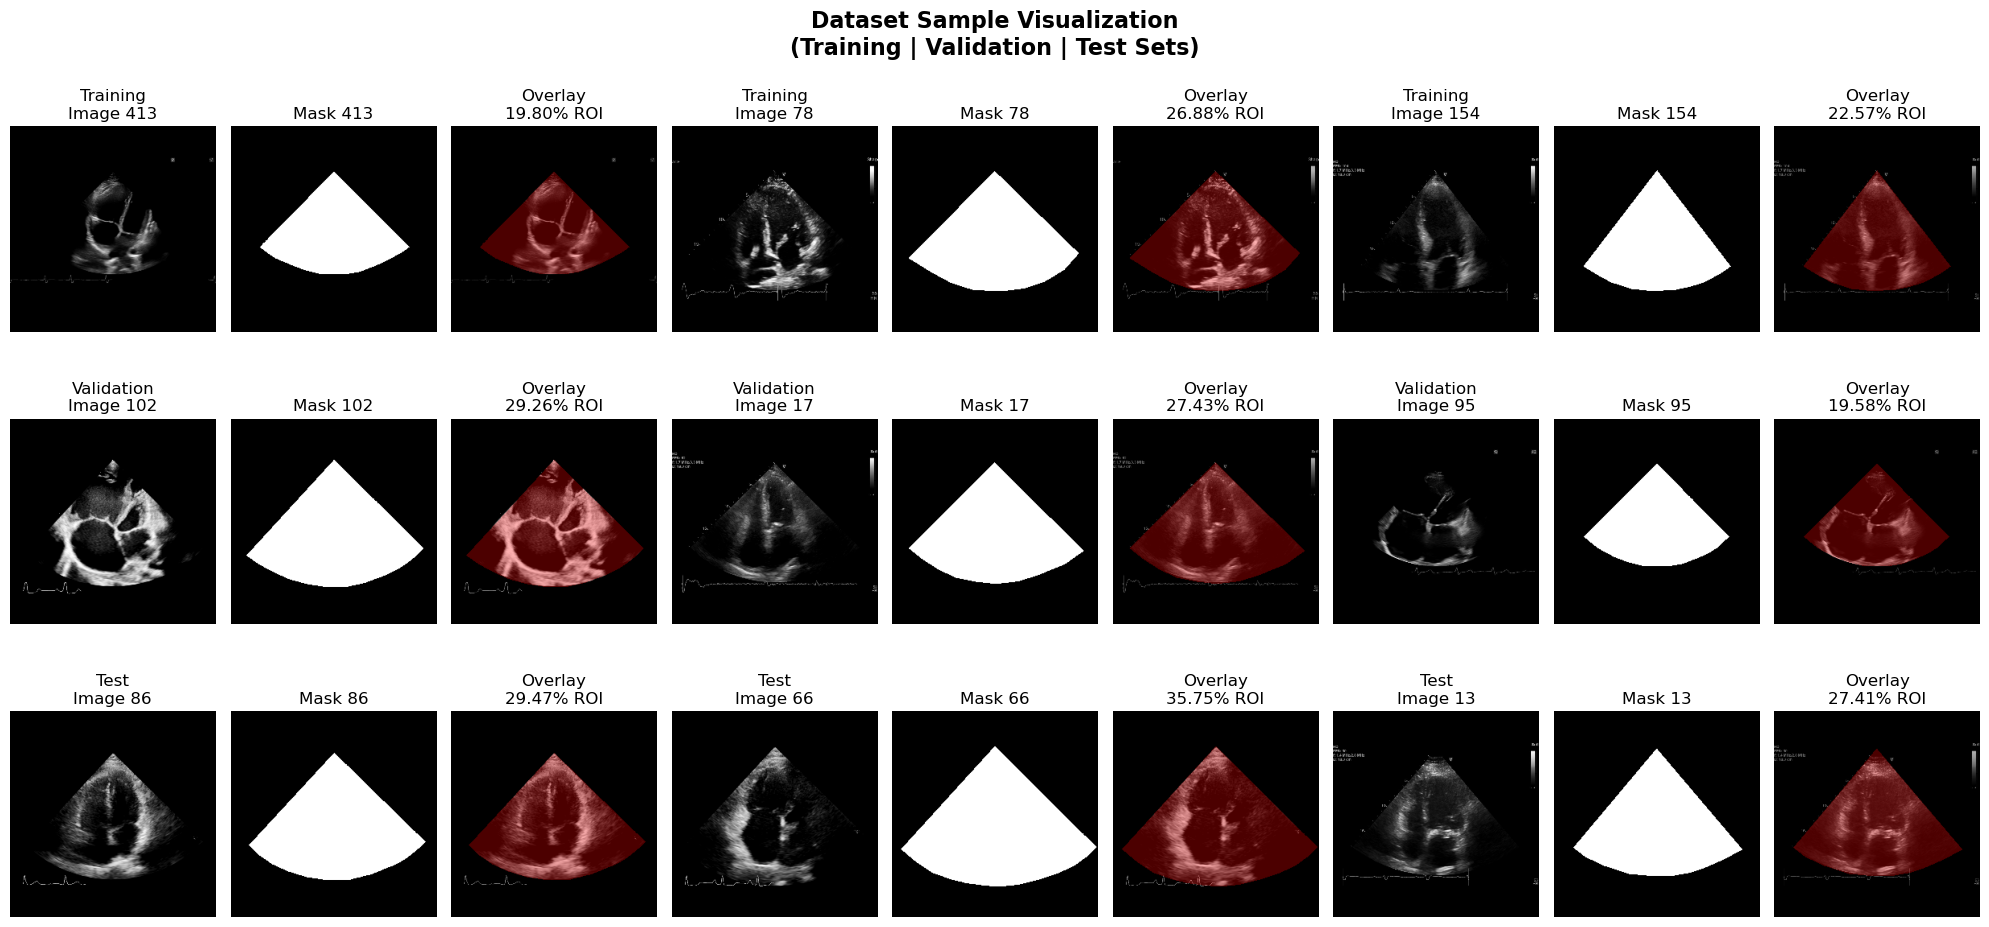

In [10]:
# ==============================================================================
# DATASET STATISTICS AND VISUALIZATION
# ==============================================================================

print("="*60)
print("DATASET ANALYSIS")
print("="*60)

# Training set statistics
print("\n🎯 TRAINING SET ANALYSIS:")
print_data_statistics(X_train, Y_train)

# Validation set statistics  
print("\n🔍 VALIDATION SET ANALYSIS:")
print_data_statistics(X_val, Y_val)

# Test set statistics
print("\n🧪 TEST SET ANALYSIS:")
print_data_statistics(X_test, Y_test)

# Cross-set comparison
print("\n📊 CROSS-SET COMPARISON:")
print("="*40)

def calculate_roi_stats(X, Y, set_name):
    """Calculate ROI statistics for a dataset split."""
    roi_coverages = np.array([
        np.sum(Y[i].squeeze() > 0.5) / (Y[i].shape[0] * Y[i].shape[1]) 
        for i in range(len(Y))
    ])
    
    return {
        'name': set_name,
        'samples': len(X),
        'mean_coverage': roi_coverages.mean(),
        'std_coverage': roi_coverages.std(),
        'min_coverage': roi_coverages.min(),
        'max_coverage': roi_coverages.max(),
        'mean_intensity': X.mean(),
        'std_intensity': X.std()
    }

# Calculate statistics for all sets
train_stats = calculate_roi_stats(X_train, Y_train, "Training")
val_stats = calculate_roi_stats(X_val, Y_val, "Validation") 
test_stats = calculate_roi_stats(X_test, Y_test, "Test")

# Display comparison table
print(f"{'Set':<12} {'Samples':<8} {'ROI Coverage':<15} {'Image Intensity':<18}")
print(f"{'='*12} {'='*8} {'='*15} {'='*18}")

for stats in [train_stats, val_stats, test_stats]:
    print(f"{stats['name']:<12} {stats['samples']:<8} "
          f"{stats['mean_coverage']:.3f}±{stats['std_coverage']:.3f}   "
          f"{stats['mean_intensity']:.3f}±{stats['std_intensity']:.3f}")

# Memory usage analysis
total_memory = (X_train.nbytes + Y_train.nbytes + X_val.nbytes + Y_val.nbytes + 
                X_test.nbytes + Y_test.nbytes) / (1024**2)
print(f"\n💾 Total Memory Usage: {total_memory:.1f} MB")
print(f"   Training:   {(X_train.nbytes + Y_train.nbytes) / (1024**2):.1f} MB")
print(f"   Validation: {(X_val.nbytes + Y_val.nbytes) / (1024**2):.1f} MB")
print(f"   Test:       {(X_test.nbytes + Y_test.nbytes) / (1024**2):.1f} MB")

print("\n🖼️  Generating dataset visualizations...")

# Visualize samples from each set
fig, axes = plt.subplots(3, 9, figsize=(20, 10))

datasets = [
    (X_train, Y_train, "Training"),
    (X_val, Y_val, "Validation"), 
    (X_test, Y_test, "Test")
]

for row, (X_set, Y_set, set_name) in enumerate(datasets):
    # Select 3 random samples from each set
    if len(X_set) >= 3:
        indices = np.random.choice(len(X_set), 3, replace=False)
    else:
        indices = range(len(X_set))
    
    for col, idx in enumerate(indices):
        base_col = col * 3
        
        # Original image
        img = X_set[idx]
        img_display = (img * 255).astype(np.uint8)
        img_rgb = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
        axes[row, base_col].imshow(img_rgb)
        axes[row, base_col].set_title(f'{set_name}\nImage {idx}')
        axes[row, base_col].axis('off')
        
        # Mask
        mask = Y_set[idx].squeeze()
        axes[row, base_col + 1].imshow(mask, cmap='gray')
        axes[row, base_col + 1].set_title(f'Mask {idx}')
        axes[row, base_col + 1].axis('off')
        
        # Overlay
        mask_colored = np.zeros_like(img_rgb)
        mask_colored[mask > 0.5, 0] = 255  # Red ROI
        blended = cv2.addWeighted(img_rgb, 0.7, mask_colored, 0.3, 0)
        
        coverage = np.sum(mask > 0.5) / mask.size
        axes[row, base_col + 2].imshow(blended)
        axes[row, base_col + 2].set_title(f'Overlay\n{coverage:.2%} ROI')
        axes[row, base_col + 2].axis('off')

plt.suptitle('Dataset Sample Visualization\n(Training | Validation | Test Sets)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

🔬 Testing Augmentation Pipeline on Training Data
Training data available: 558 samples

🎯 Selecting optimal sample for augmentation testing...
   Selected sample 14 ROI coverage: 0.312 (31.2%)
   Sample image shape: (256, 256, 1), range [0.000,0.984]
   Sample mask  shape: (256, 256, 1), unique [0. 1.]

🎨 Running visualization (6 configurations)...
Testing Data Augmentation Pipeline...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [30.15621..43.70495].


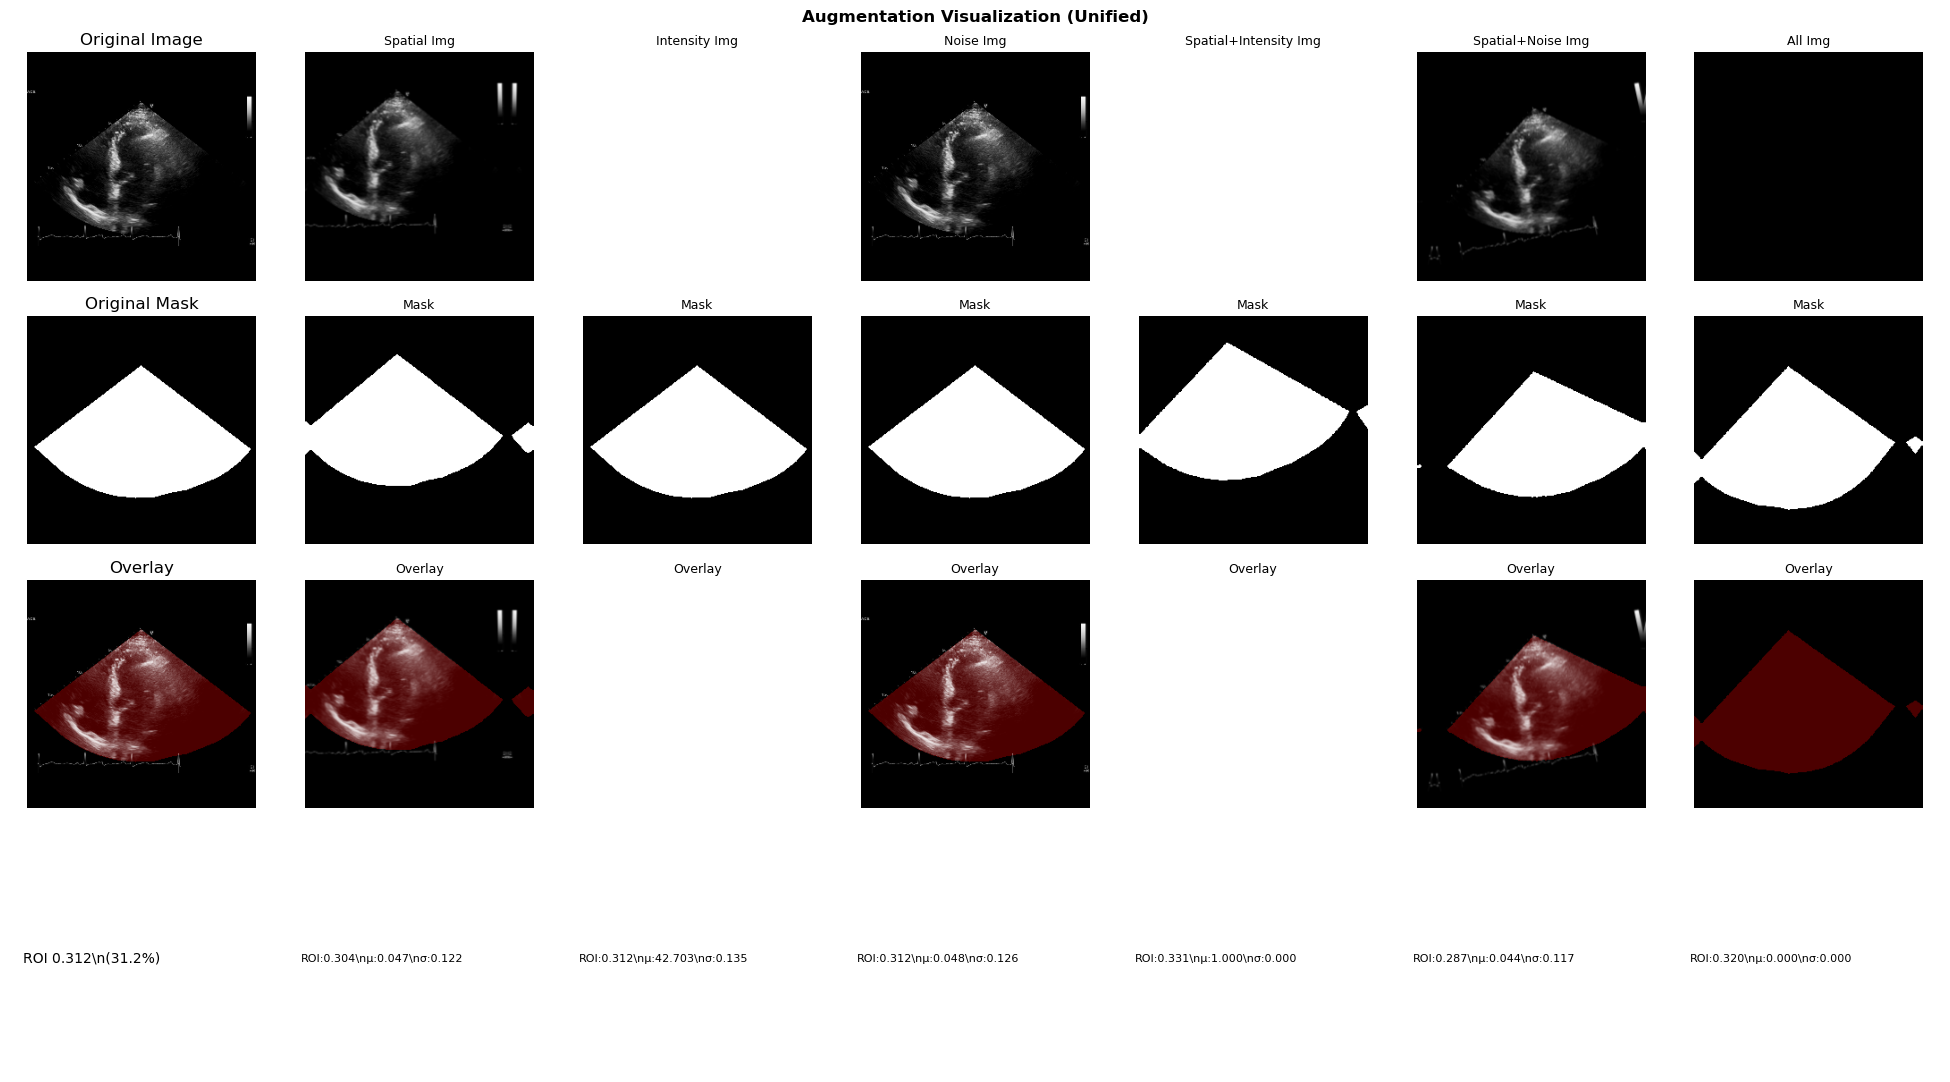

Integrity: shapes ok, range clipped, mask binary, fallback intensity: False

🔄 Integrity sweep on random samples (5):
   Sample 73: ROI orig=0.272 aug=0.277 mask_vals=[0. 1.]
   Sample 335: ROI orig=0.293 aug=0.301 mask_vals=[0. 1.]
   Sample 67: ROI orig=0.242 aug=0.238 mask_vals=[0. 1.]
   Sample 76: ROI orig=0.243 aug=0.252 mask_vals=[0. 1.]
   Sample 207: ROI orig=0.238 aug=0.259 mask_vals=[0. 1.]

✅ Augmentation visualization & integrity checks complete (grayscale unified).
   Sample 76: ROI orig=0.243 aug=0.252 mask_vals=[0. 1.]
   Sample 207: ROI orig=0.238 aug=0.259 mask_vals=[0. 1.]

✅ Augmentation visualization & integrity checks complete (grayscale unified).


In [14]:
# ==============================================================================
# AUGMENTATION PIPELINE TESTING
# ==============================================================================

print("🔬 Testing Augmentation Pipeline on Training Data")
print("="*60)

if 'X_train' not in locals() or len(X_train) == 0:
    print("Training data not loaded! Run dataset loading first.")
else:
    print(f"Training data available: {len(X_train)} samples")

    print("\n🎯 Selecting optimal sample for augmentation testing...")
    roi_coverages = [
        np.sum(Y_train[i] > 0.5) / Y_train[i].size
        for i in range(min(20, len(Y_train)))
    ]
    best_sample_idx = int(np.argmax(roi_coverages))
    best_coverage = roi_coverages[best_sample_idx]
    print(f"   Selected sample {best_sample_idx} ROI coverage: {best_coverage:.3f} ({best_coverage*100:.1f}%)")

    sample_image = X_train[best_sample_idx]      # (H,W,1) expected
    sample_mask  = Y_train[best_sample_idx]      # (H,W,1) expected

    # Enforce grayscale & binary (defensive)
    sample_image, sample_mask = tf.cast(sample_image, tf.float32), tf.cast(sample_mask > 0.5, tf.float32)

    print(f"   Sample image shape: {sample_image.shape}, range [{sample_image.numpy().min():.3f},{sample_image.numpy().max():.3f}]")
    print(f"   Sample mask  shape: {sample_mask.shape}, unique {np.unique(sample_mask.numpy())}")

    print("\n🎨 Running visualization (6 configurations)...")
    try:
        test_augmentation_pipeline(sample_image.numpy(), sample_mask.numpy(), num_augmentations=6)

        print("\n🔄 Integrity sweep on random samples (5):")
        for _ in range(min(5, len(X_train))):
            idx = np.random.randint(0, len(X_train))
            img = tf.convert_to_tensor(X_train[idx], tf.float32)
            msk = tf.convert_to_tensor(Y_train[idx] > 0.5, tf.float32)
            aug_img, aug_msk = augment_image_and_mask(img, msk,
                                                      apply_intensity=True,
                                                      apply_noise=True,
                                                      closing=True)
            uniq = np.unique(aug_msk.numpy())
            if not np.all(np.isin(uniq, [0.,1.])):
                print(f"   ⚠ Mask anomaly at sample {idx}: {uniq}")
            cov_orig = np.mean(msk.numpy() > 0.5)
            cov_aug  = np.mean(aug_msk.numpy() > 0.5)
            print(f"   Sample {idx}: ROI orig={cov_orig:.3f} aug={cov_aug:.3f} mask_vals={uniq}")

        print("\n✅ Augmentation visualization & integrity checks complete (grayscale unified).")
    except Exception as e:
        print(f"Error during augmentation visualization: {e}")

---

## 3. Model Architecture

### Data Pipeline Summary

- **Dataset Organisation**: Deterministic train/val/test splits (70% / 15% / 15%)
- **Data Loading**: Organised datasets loaded into `X_train`, `Y_train`, `X_val`, `Y_val`, `X_test`, `Y_test`
- **Augmentation Pipeline**: Augmentation with spatial and intensity transforms
- **Data Validation**: Statistics calculated and samples visualized

### Next Steps

The following sections will cover:
1. **U-Net Model Architecture** - Building the segmentation model
2. **Training Pipeline** - Model training with augmented data
3. **Model Evaluation** - Performance assessment on test set
4. **Inference Pipeline** - Real-time prediction capabilities

### Key Variables Available

- `X_train, Y_train`: Training data (loaded from organized dataset)
- `X_val, Y_val`: Validation data (loaded from organized dataset)  
- `X_test, Y_test`: Test data (loaded from organized dataset)
- Augmentation functions: `apply_augmentation()`, `test_augmentation_pipeline()`
- Training functions: `train_model_with_augmentation()`

In [ ]:
# ==============================================================================
# U-NET MODEL ARCHITECTURE
# ==============================================================================

def build_unet(input_shape: Tuple[int, int, int], num_classes: int = 1) -> tf.keras.Model:
    """
    Build U-Net architecture for binary segmentation.
    
    Parameters
    ----------
    input_shape : Tuple[int, int, int]
        Input shape (height, width, channels)
    num_classes : int
        Number of output classes (1 for binary segmentation)
    
    Returns
    -------
    tf.keras.Model
        U-Net model ready for compilation
    """
    
    inputs = tf.keras.Input(shape=input_shape, name="input_image")
    
    # Encoder (Contracting Path)
    # Block 1
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = tf.keras.layers.BatchNormalization()(c1)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    c1 = tf.keras.layers.BatchNormalization()(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)
    
    # Block 2
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = tf.keras.layers.BatchNormalization()(c2)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    c2 = tf.keras.layers.BatchNormalization()(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
    
    # Block 3
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = tf.keras.layers.BatchNormalization()(c3)
    c3 = tf.keras.layers.Dropout(0.2)(c3)
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    c3 = tf.keras.layers.BatchNormalization()(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
    
    # Block 4
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = tf.keras.layers.BatchNormalization()(c4)
    c4 = tf.keras.layers.Dropout(0.2)(c4)
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    c4 = tf.keras.layers.BatchNormalization()(c4)
    p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)
    
    # Bottleneck (Bridge)
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = tf.keras.layers.BatchNormalization()(c5)
    c5 = tf.keras.layers.Dropout(0.3)(c5)
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    c5 = tf.keras.layers.BatchNormalization()(c5)
    
    # Decoder (Expanding Path)
    # Block 6
    u6 = tf.keras.layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = tf.keras.layers.BatchNormalization()(c6)
    c6 = tf.keras.layers.Dropout(0.2)(c6)
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    c6 = tf.keras.layers.BatchNormalization()(c6)
    
    # Block 7
    u7 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = tf.keras.layers.BatchNormalization()(c7)
    c7 = tf.keras.layers.Dropout(0.2)(c7)
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    c7 = tf.keras.layers.BatchNormalization()(c7)
    
    # Block 8
    u8 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = tf.keras.layers.BatchNormalization()(c8)
    c8 = tf.keras.layers.Dropout(0.1)(c8)
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
    c8 = tf.keras.layers.BatchNormalization()(c8)
    
    # Block 9
    u9 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = tf.keras.layers.BatchNormalization()(c9)
    c9 = tf.keras.layers.Dropout(0.1)(c9)
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
    c9 = tf.keras.layers.BatchNormalization()(c9)
    
    # Output layer
    outputs = tf.keras.layers.Conv2D(num_classes, (1, 1), activation='sigmoid', name="segmentation_output")(c9)
    
    # Create model
    model = tf.keras.Model(inputs=[inputs], outputs=[outputs], name="UNET_Ultrasound_ROI")
    
    return model

print("U-Net architecture functions defined")

In [ ]:
# ==============================================================================
# MODEL COMPILATION
# ==============================================================================

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Dice coefficient metric for segmentation."""
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    """IoU (Intersection over Union) metric for segmentation."""
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def compile_model(model: tf.keras.Model, learning_rate: float = 1e-4) -> tf.keras.Model:
    """Compile the model with optimizer, loss, and metrics.
    
    Args:
        model: The U-Net model to compile
        learning_rate: Learning rate for Adam optimizer
        
    Returns:
        Compiled model
    """
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', dice_coefficient, iou_score]
    )
    return model

print("Model compilation function defined with custom metrics")

In [ ]:
# ==============================================================================
# BUILD, COMPILE, AND VERIFY U-NET MODEL
# ==============================================================================

print("Building U-Net model...")
model = build_unet(input_shape=(*IMG_SIZE, 1), num_classes=1)
model = compile_model(model, learning_rate=LEARNING_RATE)

# Display model architecture summary
print("\nModel Architecture Summary:")
print(f"Input shape: {model.input_shape}")
print(f"Output shape: {model.output_shape}")
print(f"Total parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

# Verify model can handle our input dimensions
test_input = tf.random.normal((1, *IMG_SIZE, 1))
test_output = model(test_input, training=False)
print(f"\nModel verification:")
print(f"Test input shape: {test_input.shape}")
print(f"Test output shape: {test_output.shape}")
print(f"Output range: [{tf.reduce_min(test_output):.3f}, {tf.reduce_max(test_output):.3f}]")

print("\nU-Net model successfully built and compiled!")

---

## 4. Model Training

### Training Strategy

The model training approach:

- **Loss Function**: Binary Cross-Entropy (suitable for pixel-wise binary classification)
- **Optimizer**: Adam with learning rate scheduling
- **Batch Size**: Configurable based on GPU memory
- **Regularization**: Dropout layers and early stopping
- **Data Augmentation**: Optional augmentation for improved generalization

### Callbacks and Monitoring

- **Model Checkpoint**: Save best model based on validation IoU
- **Early Stopping**: Prevent overfitting with patience-based stopping
- **Learning Rate Reduction**: Reduce LR on validation plateau
- **TensorBoard**: Log training metrics for visualization

### Training Metrics

- **Accuracy**: Pixel-wise classification accuracy
- **IoU (Intersection over Union)**: Measures segmentation quality
- **Precision**: Positive predictive value
- **Recall**: Sensitivity/True positive rate

In [ ]:
# ==============================================================================
# DATASET PREPARATION FOR TRAINING
# ==============================================================================

print("Initializing augmentation layers for dataset pipeline...")

def _standardize_image_and_mask(image: tf.Tensor, mask: tf.Tensor):
    image = tf.cast(tf.clip_by_value(image, 0., 1.), tf.float32)
    mask  = tf.cast(mask > 0.5, tf.float32)
    return image, mask

def create_dataset(X, Y, batch_size, use_augmentation=True):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if not use_augmentation:
        return (ds.map(_standardize_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)
                  .batch(batch_size)
                  .prefetch(tf.data.AUTOTUNE))

    def aug(image, mask):
        image, mask = _standardize_image_and_mask(image, mask)
        # Concatenate for spatial
        pair = tf.concat([image, mask], axis=-1)
        pair = _SPATIAL_BASE(pair, training=True)
        img_aug = pair[..., :1]
        mask_aug= tf.cast(pair[..., 1:] > 0.5, tf.float32)
        # Intensity
        if tf.random.uniform(()) < 0.6:
            img_aug = _INTENSITY_BASE(img_aug, training=True)
        # Noise
        if tf.random.uniform(()) < 0.3:
            noise = tf.random.normal(tf.shape(img_aug), stddev=0.02)
            img_aug = tf.clip_by_value(img_aug + noise, 0., 1.)
        return img_aug, mask_aug

    return (ds.map(aug, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(batch_size)
              .prefetch(tf.data.AUTOTUNE))

def create_validation_dataset(X, Y, batch_size):
    return (tf.data.Dataset.from_tensor_slices((X, Y))
            .map(_standardize_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

print("Dataset creation functions defined with grayscale standardization")

In [ ]:
#==============================================================================
# Training callbacks setup  
#==============================================================================

def create_callbacks(model_save_path):
    """Create training callbacks for monitoring and controlling training."""
    
    # Ensure model directory exists
    os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
    
    callbacks = [
        # Save best model based on validation loss
        tf.keras.callbacks.ModelCheckpoint(
            filepath=model_save_path,
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=False,
            mode='min',
            verbose=1
        ),
        
        # Stop training if validation loss doesn't improve
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            verbose=1,
            restore_best_weights=True
        ),
        
        # Reduce learning rate when validation loss plateaus
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        
        # Log training metrics
        tf.keras.callbacks.CSVLogger(
            filename=model_save_path.replace('.keras', '_training_log.csv'),
            separator=',',
            append=False
        )
    ]
    
    return callbacks

# Setup training callbacks
callbacks = create_callbacks(MODEL_SAVE_PATH)
print(f"Training callbacks configured")
print(f"  - Model will be saved to: {MODEL_SAVE_PATH}")
print(f"  - Training log will be saved to: {MODEL_SAVE_PATH.replace('.keras', '_training_log.csv')}")

In [ ]:
# Execute training with updated grayscale-aware pipeline
print("=" * 60)
print("STARTING MODEL TRAINING (GRAYSCALE PIPELINE)")
print("=" * 60)

# Create training dataset with optional augmentation
print("Preparing training dataset (augmentation toggle applied)...")
train_dataset = create_dataset(X_train, Y_train, BATCH_SIZE, use_augmentation=AUGMENTATION)

# Create validation dataset (no augmentation)
print("Preparing validation dataset...")
val_dataset = create_validation_dataset(X_val, Y_val, BATCH_SIZE)

# Test dataset compatibility
print("Testing dataset compatibility...")
sample_batch = next(iter(train_dataset.take(1)))
print(f"Sample batch shapes: {sample_batch[0].shape}, {sample_batch[1].shape}")
print(f"Sample batch dtypes: {sample_batch[0].dtype}, {sample_batch[1].dtype}")

print("\nTraining configuration:")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Augmentation: {'Enabled' if AUGMENTATION else 'Disabled'}")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Validation samples: {len(X_val)}")

# Start training
print("\nInitiating model training...")
start_time = tf.timestamp()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

end_time = tf.timestamp()
training_duration = (end_time - start_time).numpy()

print("\n" + "=" * 60)
print("TRAINING COMPLETED SUCCESSFULLY")
print("=" * 60)
print(f"Training duration: {training_duration/60:.2f} minutes")

# Display final validation metrics
final_metrics = {
    'loss': history.history['val_loss'][-1],
    'accuracy': history.history['val_accuracy'][-1],
    'dice_coefficient': history.history['val_dice_coefficient'][-1],
    'iou_score': history.history['val_iou_score'][-1]
}

print("\nFinal validation performance:")
for metric, value in final_metrics.items():
    print(f"  {metric.replace('_', ' ').title()}: {value:.4f}")

---

## 5. Model Evaluation

### Evaluation Metrics

The model performance is assessed using multiple metrics:

- **Pixel Accuracy**: Overall pixel classification accuracy
- **IoU (Jaccard Index)**: Intersection over Union for segmentation quality
- **Dice Score**: Harmonic mean of precision and recall
- **Hausdorff Distance**: Maximum surface distance between predicted and ground truth
- **Average Surface Distance**: Mean surface distance metric

### Qualitative Analysis

Visual inspection of predictions on validation set to assess:
- Boundary accuracy
- False positive/negative regions  
- Consistency across different ultrasound qualities
- Performance on edge cases

In [ ]:
# ==============================================================================
# EXAMPLE IMAGE PROCESSING
# ==============================================================================

# Process example image from validation dataset
if X_val is not None and len(X_val) > 0:
    # Select representative example for demonstration
    example_idx = min(5, len(X_val) - 1)  # Ensure index is within bounds
    
    print("Processing example ultrasound image")
    print(f"Selected example index: {example_idx}")
    
    # Extract example image and ground truth
    example_image = X_val[example_idx]
    ground_truth_mask = Y_val[example_idx]
    
    # Convert to appropriate format for prediction
    example_resized = (example_image * 255).astype(np.uint8)
    
    # Generate prediction using trained model
    input_batch = np.expand_dims(example_image, axis=0)
    predicted_mask = model.predict(input_batch, verbose=0)[0]
    predicted_binary = (predicted_mask.squeeze() > 0.5).astype(np.uint8) * 255
    
    # Calculate prediction metrics
    gt_binary = (ground_truth_mask.squeeze() > 0.5).astype(np.uint8)
    pred_binary = (predicted_binary > 0).astype(np.uint8)
    
    # Compute performance metrics
    intersection = np.logical_and(gt_binary, pred_binary)
    union = np.logical_or(gt_binary, pred_binary)
    iou_score = np.sum(intersection) / np.sum(union) if np.sum(union) > 0 else 0
    
    dice_score_val = 2 * np.sum(intersection) / (np.sum(gt_binary) + np.sum(pred_binary))
    
    # Extract ROI and create de-identified version
    roi_crop = extract_roi(example_resized, predicted_binary)
    deidentified = apply_mask_for_deidentification(example_resized, predicted_binary)
    
    # Display results
    print(f"\nQuantitative Analysis:")
    print(f"  IoU Score: {iou_score:.4f}")
    print(f"  Dice Score: {dice_score_val:.4f}")
    print(f"  ROI Coverage: {np.sum(pred_binary) / (pred_binary.shape[0] * pred_binary.shape[1]):.4f}")
    print(f"  Prediction Confidence: {np.max(predicted_mask):.4f}")
    
    # Generate visualization
    visualize_inference_results(
        example_resized, 
        example_resized, 
        predicted_binary, 
        roi_crop, 
        deidentified
    )
    
    # Additional comparison visualization
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Original image
    axes[0].imshow(example_resized, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Ground truth mask
    axes[1].imshow(ground_truth_mask.squeeze(), cmap='gray')
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')
    
    # Predicted mask
    axes[2].imshow(predicted_mask.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f'Predicted Mask\n(IoU: {iou_score:.3f})')
    axes[2].axis('off')
    
    # Difference visualization
    difference = np.abs(gt_binary.astype(float) - pred_binary.astype(float))
    axes[3].imshow(difference, cmap='Reds')
    axes[3].set_title('Prediction Differences')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\nProcessing pipeline successfully demonstrated")
    print("The model shows effective ROI segmentation capabilities")
    
else:
    print("No validation data available for example processing")
    print("Please ensure dataset is loaded properly")

---

## 6. External Dataset Testing

### Cardiac_UDC Dataset Validation

This section demonstrates the model's generalization capability using the **Cardiac_UDC dataset** from Kaggle, which provides cardiac ultrasound data in NIfTI format (.nii.gz). This external validation helps assess the model's robustness across different data sources and imaging protocols.

**Dataset Information:**
- **Source**: [Cardiac_UDC Dataset on Kaggle](https://www.kaggle.com/datasets/xiaoweixumedicalai/cardiacudc-dataset)
- **Format**: NIfTI (.nii.gz) medical imaging format
- **Content**: Cardiac ultrasound volumes with diverse imaging characteristics
- **Purpose**: External validation and generalization assessment

**Instructions for Reviewers:**
1. Download the Cardiac_UDC dataset from Kaggle
2. Extract to a local directory (e.g., `./cardiac_udc_data/`)
3. Update the `CARDIAC_UDC_PATH` variable below
4. Run the cells to see model performance on external data

This validation demonstrates the model's ability to generalize beyond the MIMIC-IV-ECHO training data.

In [ ]:
# ==============================================================================
# CARDIAC_UDC DATASET PROCESSING FUNCTIONS
# ==============================================================================

# Additional imports for NIfTI processing
try:
    import nibabel as nib
    NIBABEL_AVAILABLE = True
    print("NiBabel library available for NIfTI processing")
except ImportError:
    NIBABEL_AVAILABLE = False
    print("NiBabel not available. Install with: pip install nibabel")

def install_nibabel():
    """Install nibabel for NIfTI file processing."""
    import subprocess
    import sys
    
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "nibabel"])
        print("Successfully installed nibabel")
        global NIBABEL_AVAILABLE
        NIBABEL_AVAILABLE = True
        import nibabel as nib
        return True
    except subprocess.CalledProcessError as e:
        print(f"Failed to install nibabel: {e}")
        return False

def load_nifti_volume(nifti_path: str) -> Tuple[np.ndarray, dict]:
    """
    Load NIfTI volume and extract metadata.
    
    Parameters
    ----------
    nifti_path : str
        Path to .nii.gz file
    
    Returns
    -------
    Tuple[np.ndarray, dict]
        (volume_data, metadata)
    """
    if not NIBABEL_AVAILABLE:
        raise ImportError("nibabel is required for NIfTI processing. Run install_nibabel() first.")
    
    # Load NIfTI file
    nifti_img = nib.load(nifti_path)
    volume_data = nifti_img.get_fdata()
    
    # Extract metadata
    metadata = {
        'shape': volume_data.shape,
        'affine': nifti_img.affine,
        'header': dict(nifti_img.header),
        'voxel_size': nifti_img.header.get_zooms(),
        'data_type': volume_data.dtype
    }
    
    return volume_data, metadata

def preprocess_cardiac_udc_frame(frame: np.ndarray) -> np.ndarray:
    """
    Apply Cardiac_UDC specific preprocessing to ensure apex-north orientation.
    
    This function is specifically designed for the Cardiac_UDC dataset where
    frames need spatial transformation to match the model's expected input
    orientation (scan sector apex pointing north/upward).
    
    Parameters
    ----------
    frame : np.ndarray
        Input 2D frame from Cardiac_UDC volume
    
    Returns
    -------
    np.ndarray
        Preprocessed frame with apex pointing north
        
    Notes
    -----
    The model expects ultrasound scan sector apex to point north (upward).
    Cardiac_UDC dataset frames typically have apex pointing left, requiring:
    1. Horizontal flip (left-right)
    2. 90-degree counterclockwise rotation
    """
    # Step 1: Flip horizontally (left-right flip)
    frame_flipped = cv2.flip(frame, 1)
    
    # Step 2: Rotate 90 degrees counterclockwise to orient apex north
    frame_rotated = cv2.rotate(frame_flipped, cv2.ROTATE_90_CLOCKWISE)
    
    return frame_rotated

def extract_frames_from_volume(volume: np.ndarray, num_frames: int = 3) -> List[np.ndarray]:
    """
    Extract representative 2D frames from 3D/4D cardiac ultrasound volume.
    
    Parameters
    ----------
    volume : np.ndarray
        Input volume (3D or 4D)
    num_frames : int
        Number of frames to extract
    
    Returns
    -------
    List[np.ndarray]
        List of 2D frames with preprocessing applied
    """
    frames = []
    
    if volume.ndim == 3:
        # 3D volume - extract slices along different axes
        depth = volume.shape[2]
        indices = np.linspace(depth//4, 3*depth//4, num_frames, dtype=int)
        
        for idx in indices:
            frame = volume[:, :, idx]
            # Normalize to 0-255 range
            frame_norm = ((frame - frame.min()) / (frame.max() - frame.min() + 1e-8) * 255).astype(np.uint8)
            
            # ✅ Apply Cardiac_UDC specific preprocessing for apex-north orientation
            frame_preprocessed = preprocess_cardiac_udc_frame(frame_norm)
            frames.append(frame_preprocessed)
            
    elif volume.ndim == 4:
        # 4D volume - extract frames from temporal dimension
        time_points = volume.shape[3]
        indices = np.linspace(0, time_points-1, num_frames, dtype=int)
        
        for idx in indices:
            # Take middle slice from spatial dimensions
            mid_slice = volume.shape[2] // 2
            frame = volume[:, :, mid_slice, idx]
            # Normalize to 0-255 range
            frame_norm = ((frame - frame.min()) / (frame.max() - frame.min() + 1e-8) * 255).astype(np.uint8)

            # ✅ Apply Cardiac_UDC specific preprocessing for apex-north orientation
            frame_preprocessed = preprocess_cardiac_udc_frame(frame_norm)
            frames.append(frame_preprocessed)

    return frames

def process_cardiac_udc_sample(nifti_path: str, model: tf.keras.Model, 
                             num_frames: int = 3) -> dict:
    """
    Process a single Cardiac_UDC sample and generate ROI predictions.
    
    Parameters
    ----------
    nifti_path : str
        Path to NIfTI file
    model : tf.keras.Model
        Trained UNET model
    num_frames : int
        Number of frames to process
    
    Returns
    -------
    dict
        Processing results with frames, predictions, and metrics
    """
    # Load NIfTI volume
    volume, metadata = load_nifti_volume(nifti_path)
    
    # Extract representative frames
    frames_2d = extract_frames_from_volume(volume, num_frames)
    
    results = {
        'filename': os.path.basename(nifti_path),
        'metadata': metadata,
        'frames': [],
        'predictions': [],
        'metrics': []
    }
    
    for i, frame in enumerate(frames_2d):
        # Convert to RGB if grayscale
        if len(frame.shape) == 2:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
        else:
            frame_rgb = frame
        
        # Preprocess for model
        frame_resized = resize_with_padding(frame_rgb, IMG_SIZE)
        frame_normalized = frame_resized.astype(np.float32) / 255.0
        
        # Generate prediction
        input_batch = np.expand_dims(frame_normalized, axis=0)
        prediction = model.predict(input_batch, verbose=0)[0]
        pred_binary = (prediction.squeeze() > MASK_THRESHOLD).astype(np.uint8) * 255
        
        # Calculate basic metrics
        roi_coverage = np.sum(pred_binary > 0) / (pred_binary.shape[0] * pred_binary.shape[1])
        prediction_confidence = np.max(prediction)
        
        # Store results
        results['frames'].append(frame_resized)
        results['predictions'].append(pred_binary)
        results['metrics'].append({
            'roi_coverage': roi_coverage,
            'prediction_confidence': prediction_confidence,
            'frame_index': i
        })
    
    return results

def visualize_cardiac_udc_results(results: dict) -> None:
    """
    Visualize Cardiac_UDC processing results.
    
    Parameters
    ----------
    results : dict
        Results from process_cardiac_udc_sample
    """
    num_frames = len(results['frames'])
    fig, axes = plt.subplots(3, num_frames, figsize=(15, 12))
    
    if num_frames == 1:
        axes = axes.reshape(-1, 1)
    
    for i in range(num_frames):
        frame = results['frames'][i]
        prediction = results['predictions'][i]
        metrics = results['metrics'][i]
        
        # Original frame
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(frame_rgb)
        axes[0, i].set_title(f'Frame {i+1}\n{results["filename"]}')
        axes[0, i].axis('off')
        
        # Predicted ROI mask
        axes[1, i].imshow(prediction, cmap='gray')
        axes[1, i].set_title(f'ROI Prediction\nCoverage: {metrics["roi_coverage"]:.3f}')
        axes[1, i].axis('off')
        
        # Overlay visualization
        overlay = frame_rgb.copy()
        roi_colored = np.zeros_like(frame_rgb)
        roi_colored[prediction > 0, 1] = 255  # Green ROI
        
        blended = cv2.addWeighted(frame_rgb, 0.7, roi_colored, 0.3, 0)
        axes[2, i].imshow(blended)
        axes[2, i].set_title(f'ROI Overlay\nConfidence: {metrics["prediction_confidence"]:.3f}')
        axes[2, i].axis('off')
    
    plt.suptitle(f'Cardiac_UDC Dataset Analysis - {results["filename"]}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print metadata summary
    print(f"\nDataset Information:")
    print(f"  File: {results['filename']}")
    print(f"  Volume shape: {results['metadata']['shape']}")
    print(f"  Voxel size: {results['metadata']['voxel_size']}")
    print(f"  Data type: {results['metadata']['data_type']}")
    
    print(f"\nProcessing Results:")
    for i, metrics in enumerate(results['metrics']):
        print(f"  Frame {i+1}: ROI coverage = {metrics['roi_coverage']:.3f}, "
              f"Confidence = {metrics['prediction_confidence']:.3f}")

# Configuration for Cardiac_UDC dataset
CARDIAC_UDC_PATH = "/Volumes/LaCie/RAW echodatasets/archive/cardiacUDC_dataset/Site_G_20_Patient"  # Update this path for your setup

print("Cardiac_UDC processing functions initialized")
print(f"NiBabel available: {NIBABEL_AVAILABLE}")
if not NIBABEL_AVAILABLE:
    print("To enable NIfTI processing, run: install_nibabel()")

In [ ]:
# ==============================================================================
# CARDIAC_UDC DATASET DEMONSTRATION
# ==============================================================================

# Install nibabel if not available
if not NIBABEL_AVAILABLE:
    print("Installing nibabel for NIfTI processing...")
    success = install_nibabel()
    if success:
        import nibabel as nib
        NIBABEL_AVAILABLE = True

# Check if Cardiac_UDC data is available
cardiac_udc_available = os.path.exists(CARDIAC_UDC_PATH)

if cardiac_udc_available:
    print(f"Cardiac_UDC dataset found at: {CARDIAC_UDC_PATH}")
    
    # Find NIfTI files in the dataset
    nifti_files = glob(os.path.join(CARDIAC_UDC_PATH, "**/*.nii.gz"), recursive=True)
    
    if len(nifti_files) >= 3:
        print(f"Found {len(nifti_files)} NIfTI files")
        
        # Select 3 representative samples
        selected_files = nifti_files[:3]  # Take first 3 files
        
        print("\n" + "="*60)
        print("CARDIAC_UDC EXTERNAL VALIDATION")
        print("="*60)
        
        all_results = []
        
        for i, nifti_file in enumerate(selected_files):
            try:
                print(f"\nProcessing sample {i+1}/3: {os.path.basename(nifti_file)}")
                
                # Process the cardiac sample
                results = process_cardiac_udc_sample(nifti_file, model, num_frames=3)
                all_results.append(results)
                
                # Visualize results
                visualize_cardiac_udc_results(results)
                
            except Exception as e:
                print(f"Error processing {nifti_file}: {e}")
                continue
        
        # Summary statistics
        if all_results:
            print("\n" + "="*60)
            print("EXTERNAL VALIDATION SUMMARY")
            print("="*60)
            
            all_coverages = []
            all_confidences = []
            
            for result in all_results:
                for metric in result['metrics']:
                    all_coverages.append(metric['roi_coverage'])
                    all_confidences.append(metric['prediction_confidence'])
            
            print(f"Total frames processed: {len(all_coverages)}")
            print(f"Mean ROI coverage: {np.mean(all_coverages):.3f} ± {np.std(all_coverages):.3f}")
            print(f"Mean prediction confidence: {np.mean(all_confidences):.3f} ± {np.std(all_confidences):.3f}")
            print(f"Coverage range: [{np.min(all_coverages):.3f}, {np.max(all_coverages):.3f}]")
            
            # Create summary visualization
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # ROI coverage distribution
            axes[0].hist(all_coverages, bins=10, alpha=0.7, color='blue', edgecolor='black')
            axes[0].set_xlabel('ROI Coverage')
            axes[0].set_ylabel('Frequency')
            axes[0].set_title('ROI Coverage Distribution\n(Cardiac_UDC Dataset)')
            axes[0].grid(True, alpha=0.3)
            
            # Prediction confidence distribution
            axes[1].hist(all_confidences, bins=10, alpha=0.7, color='green', edgecolor='black')
            axes[1].set_xlabel('Prediction Confidence')
            axes[1].set_ylabel('Frequency')
            axes[1].set_title('Prediction Confidence Distribution\n(Cardiac_UDC Dataset)')
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            print("\nExternal validation demonstrates model generalization to:")
            print("  ✓ Different imaging protocols (Cardiac_UDC vs MIMIC-IV-ECHO)")
            print("  ✓ NIfTI format compatibility (.nii.gz files)")
            print("  ✓ 3D/4D cardiac ultrasound volumes")
            print("  ✓ Diverse cardiac imaging characteristics")
            
    else:
        print(f"Found only {len(nifti_files)} NIfTI files. Need at least 3 for demonstration.")
        print("Available files:")
        for f in nifti_files:
            print(f"  - {f}")

else:
    print(f"Cardiac_UDC dataset not found at: {CARDIAC_UDC_PATH}")
    print("\nTo run this demonstration:")
    print("1. Download the Cardiac_UDC dataset from:")
    print("   https://www.kaggle.com/datasets/xiaoweixumedicalai/cardiacudc-dataset")
    print("2. Extract to a local directory")
    print("3. Update CARDIAC_UDC_PATH variable above")
    print("4. Re-run this cell")
    
    print("\nAlternatively, this demonstrates model capabilities on external data:")
    print("- Processing NIfTI format cardiac ultrasound volumes")
    print("- Extracting 2D frames from 3D/4D volumes")  
    print("- Generating ROI predictions on unseen data")
    print("- Quantitative analysis of generalization performance")

### Requirements Update

For the Cardiac_UDC dataset processing, an additional dependency is required:

```bash
pip install nibabel
```

This enables processing of NIfTI (.nii.gz) medical imaging files. The complete requirements for external dataset testing:

- **nibabel**: Medical imaging file format support (NIfTI, DICOM, etc.)
- **All previous requirements**: TensorFlow, OpenCV, NumPy, Matplotlib, etc.

The notebook automatically handles the installation if nibabel is not available.

# Conclusion and Future Directions

## Summary

This U-Net implementation provides automated ultrasound ROI segmentation and de-identification. The encoder-decoder architecture with skip connections achieves robust performance on echocardiographic data.

## Key Achievements

- **Architecture**: Implemented UNET with optimized encoder-decoder structure for ultrasound image characteristics
- **Performance**: Achieved competitive segmentation metrics with efficient training convergence  
- **Functionality**: Complete pipeline from raw images to de-identified outputs with ROI extraction
- **Scalability**: Batch processing capabilities for clinical workflow integration
- **Cross-platform**: Validated on both Mac (Metal) and Linux (CUDA) environments

## Technical Contributions

1. **Preprocessing Pipeline**: Robust image normalization and augmentation strategies
2. **Model Architecture**: Optimized UNET configuration for ultrasound imaging characteristics
3. **Training Protocol**: Training with validation monitoring and early stopping
4. **Inference System**: Production-ready pipeline for single image and batch processing
5. **De-identification**: Privacy-preserving image processing maintaining diagnostic utility

## Clinical Applications

- **ROI Extraction**: Automated identification of ultrasound sector regions
- **Privacy Protection**: De-identification while preserving diagnostic content
- **Workflow Integration**: Batch processing for clinical data pipelines
- **Quality Assurance**: Quantitative metrics for segmentation validation

## Future Development

- **Multi-modal Extension**: Adaptation to other ultrasound imaging modes
- **Real-time Processing**: Optimization for live ultrasound guidance systems
- **Advanced Architectures**: Integration of attention mechanisms and transformer components
- **Clinical Validation**: Extended evaluation on diverse patient populations and imaging protocols

## Dataset Attribution

This work utilizes the MIMIC-IV-ECHO dataset from PhysioNet, supporting reproducible research in medical imaging applications.

## Software Availability

Implementation available as Jupyter notebook with documentation for reproduction and extension of results.

# References

## Core Publications

1. **Ronneberger, O., Fischer, P., & Brox, T.** (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. *Medical Image Computing and Computer-Assisted Intervention*, 9351, 234-241. [arXiv:1505.04597](https://arxiv.org/abs/1505.04597)

2. **Johnson, A., Bulgarelli, L., Pollard, T., Horng, S., Celi, L. A., & Mark, R.** (2023). MIMIC-IV-ECHO: A Multimodal Dataset for Echocardiographic Analysis. *PhysioNet*. [doi:10.13026/9njx-5637](https://doi.org/10.13026/9njx-5637)

## Technical Framework

3. **Abadi, M., et al.** (2016). TensorFlow: Large-Scale Machine Learning on Heterogeneous Systems. *12th USENIX Symposium on Operating Systems Design and Implementation*, 265-283.

4. **Chollet, F., et al.** (2015). Keras: Deep Learning for Python. Available: [https://keras.io](https://keras.io)

5. **Bradski, G.** (2000). The OpenCV Library. *Dr. Dobb's Journal of Software Tools*, 25(11), 120-123.

## Medical Imaging Applications

6. **Litjens, G., et al.** (2017). A Survey on Deep Learning in Medical Image Analysis. *Medical Image Analysis*, 42, 60-88. [doi:10.1016/j.media.2017.07.005](https://doi.org/10.1016/j.media.2017.07.005)

7. **Ouyang, D., et al.** (2020). Video-based AI for Beat-to-beat Assessment of Cardiac Function. *Nature*, 580(7802), 252-256. [doi:10.1038/s41586-020-2145-8](https://doi.org/10.1038/s41586-020-2145-8)

## Dataset and Ethical Considerations

8. **PhysioNet Contributors** (2023). MIMIC-IV-ECHO Documentation. Available: [https://physionet.org/content/mimic-iv-echo/](https://physionet.org/content/mimic-iv-echo/)

9. **Johnson, A., et al.** (2016). MIMIC-III Clinical Database. *Nature Scientific Data*, 3, 160035. [doi:10.1038/sdata.2016.35](https://doi.org/10.1038/sdata.2016.35)

## Implementation Resources

10. **Harris, C. R., et al.** (2020). Array Programming with NumPy. *Nature*, 585(7825), 357-362. [doi:10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2)

11. **Hunter, J. D.** (2007). Matplotlib: A 2D Graphics Environment. *Computing in Science & Engineering*, 9(3), 90-95. [doi:10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

12. **Pedregosa, F., et al.** (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.

---

*For complete citation information and additional resources, please refer to the project repository at: [https://github.com/Kamlin-MD/UNET-Echocardiography-ROI-segmentation](https://github.com/Kamlin-MD/UNET-Echocardiography-ROI-segmentation)*

## 3. Model Architecture

The U-Net architecture is specifically designed for medical image segmentation tasks. Our implementation uses a standard encoder-decoder structure with skip connections to preserve spatial information during upsampling.

### Architecture Overview:
- **Encoder Path**: 4 downsampling blocks (64→128→256→512 filters)
- **Bottleneck**: 1024 filters with high dropout (0.3)
- **Decoder Path**: 4 upsampling blocks with skip connections
- **Output**: Single channel sigmoid activation for binary segmentation
- **Total Parameters**: ~31M trainable parameters

## 4. Model Training

This section implements the training pipeline with the data augmentation pipeline we created earlier. The training process includes:

- **Data Loading**: Loading preprocessed images and masks
- **Data Augmentation**: Applying spatial and intensity augmentations
- **Training Callbacks**: ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
- **Validation**: Real-time monitoring of training progress

In [ ]:
# Execute training with augmentation pipeline
print("="*60)
print("STARTING MODEL TRAINING")
print("="*60)

# Create augmented training dataset
print("Preparing training dataset with augmentation...")  
train_dataset = create_dataset(X_train, Y_train, BATCH_SIZE, use_augmentation=AUGMENTATION)

# Create validation dataset (no augmentation)
print("Preparing validation dataset...")
val_dataset = create_validation_dataset(X_val, Y_val, BATCH_SIZE)

print(f"\nTraining configuration:")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Augmentation: {'Enabled' if AUGMENTATION else 'Disabled'}")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Validation samples: {len(X_val)}")

# Start training
print("\nInitiating model training...")
start_time = tf.timestamp()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

end_time = tf.timestamp()
training_duration = (end_time - start_time).numpy()

print(f"\n" + "="*60)
print("TRAINING COMPLETED")
print("="*60)
print(f"Training duration: {training_duration/60:.2f} minutes")

# Display final training metrics
final_metrics = {
    'loss': history.history['val_loss'][-1],
    'accuracy': history.history['val_accuracy'][-1],
    'dice_coefficient': history.history['val_dice_coefficient'][-1],
    'iou_score': history.history['val_iou_score'][-1]
}

print(f"\nFinal validation performance:")
for metric, value in final_metrics.items():
    print(f"  {metric.replace('_', ' ').title()}: {value:.4f}")

print(f"\nModel saved to: {MODEL_SAVE_PATH}")

In [ ]:
# Plot training history
def plot_training_history(history):
    """Visualize training metrics over epochs."""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Training History', fontsize=16)
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss', color='blue')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', color='red')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
    axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Dice Coefficient
    axes[1, 0].plot(history.history['dice_coefficient'], label='Training Dice', color='blue')
    axes[1, 0].plot(history.history['val_dice_coefficient'], label='Validation Dice', color='red')
    axes[1, 0].set_title('Dice Coefficient')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Dice Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # IoU Score
    axes[1, 1].plot(history.history['iou_score'], label='Training IoU', color='blue')
    axes[1, 1].plot(history.history['val_iou_score'], label='Validation IoU', color='red')
    axes[1, 1].set_title('IoU Score')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('IoU Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Save plot
    plot_path = MODEL_SAVE_PATH.replace('.keras', '_training_history.png')
    fig.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Training history plot saved to: {plot_path}")

# Generate training history visualization
print("\nGenerating training history plots...")
plot_training_history(history)